In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from urllib.parse import urlparse
import requests
from bs4 import BeautifulSoup
import ollama
import time
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [ ]:
def search_strategy_urls(query, api_key):
    url = "https://serpapi.com/search"

    params = {
        "q": query,
        "api_key": api_key,
        "engine": "google"
    }

    response = requests.get(url, params=params)
    data = response.json()

    urls = []

    for result in data.get("organic_results", []):
        if "link" in result:
            urls.append(result["link"])

    return urls

queries = [
    "stock momentum trading strategy",
    "mean reversion stock trading strategy",
    "moving average crossover strategy stocks",
    "RSI trading strategy",
    "breakout trading strategy stocks"
]

all_urls = []
API_KEY = "SERPAPI KEY"

for query in queries:
    urls = search_strategy_urls(query, API_KEY)
    all_urls.extend(urls)

all_urls = list(set(all_urls))

In [ ]:
def scrape_strategy(url):
    domain = urlparse(url).netloc
    source = domain.removeprefix("www.").split(".")[0]

    try:
        response = requests.get(
            url,
            headers={"User-Agent": "Mozilla/5.0"},
            timeout=10
        )

        if response.status_code != 200:
            print(f"Failed: {url} ({response.status_code})")
            return None

        soup = BeautifulSoup(response.text, "html.parser")

        for tag in soup(["script", "style", "nav", "footer", "header"]):
            tag.decompose()

        text = soup.get_text(" ", strip=True)

        return {
            "source": source,
            "url": url,
            "raw_text": text
        }

    except requests.RequestException as e:
        return {
            "url": url,
            "raw_text": None,
            "error": str(e)
        }

In [7]:
strategies = []

for url in all_urls:
    strategy = scrape_strategy(url)

    if strategy is not None:
        strategies.append(strategy)

for i, strategy in enumerate(strategies, start=1):
    strategy["id"] = i

with open("data/raw_strategies.json", "w", encoding="utf-8") as f:
    json.dump(strategies, f, indent=4, ensure_ascii=False)

Failed: https://www.reddit.com/r/swingtrading/comments/1fy6c45/im_a_professional_trader_and_this_is_my_guide_on/ (403)
Failed: https://www.avatrade.com/education/technical-analysis-indicators-strategies/rsi-trading-strategies (403)
Failed: https://www.investopedia.com/trading/introduction-to-momentum-trading/ (402)
Failed: https://www.investopedia.com/terms/c/crossover.asp (402)
Failed: https://www.investopedia.com/terms/r/rsi.asp (402)
Failed: https://www.reddit.com/r/algotrading/comments/1ov3g5r/moving_average_crossover_strategy/ (403)
Failed: https://www.reddit.com/r/Daytrading/comments/1r961dm/is_mean_reversion_the_best_strategy_for_trading/ (403)
Failed: https://www.reddit.com/r/Daytrading/comments/1tflz13/the_only_strategy_that_works_for_me_momentum/ (403)
Failed: https://www.investopedia.com/terms/m/meanreversion.asp (402)
Failed: https://www.investopedia.com/articles/trading/08/trading-breakouts.asp (402)
Failed: https://www.warriortrading.com/momentum-day-trading-strategy/ (40

In [ ]:
with open("data/raw_strategies.json", "r", encoding="utf-8") as f:
    strategies = json.load(f)

In [30]:
type(strategies)

list

In [31]:
def extract_strategy(raw_text):
    prompt = f"""
Extract ONE primary stock trading strategy from the text below.

Return exactly:

{{
  "strategy_type": null,
  "direction": null,
  "asset_type": null,
  "timeframe": null,
  "indicators": [],
  "entry_conditions": [],
  "exit_conditions": [],
  "stop_loss_percent": null,
  "take_profit_percent": null
}}

Rules:
- Extract only ONE primary strategy.
- strategy_type, direction, asset_type, and timeframe must each be
  either ONE string or null.
- indicators, entry_conditions, and exit_conditions must always be lists.
- stop_loss_percent and take_profit_percent must be numbers or null.
- Use null, never "Unknown".
- If multiple timeframes appear, choose the timeframe that belongs to
  the primary strategy.
- Do not invent missing information.
- Ignore unrelated webpage content.

TEXT:
{raw_text[:8000]}
"""

    response = ollama.chat(
        model="llama3.2:3b",
        messages=[
            {"role": "user", "content": prompt}
        ],
        format="json"
    )

    return json.loads(response["message"]["content"])

In [32]:
result = extract_strategy(strategies[0]["raw_text"])
print(result)


{'strategy_type': 'Moving Average Crossover', 'direction': None, 'asset_type': 'stock', 'timeframe': 'daily', 'indicators': [], 'entry_conditions': [{'type': 'crossover', 'fast_ma_period': 50, 'slow_ma_period': 200}], 'exit_conditions': [], 'stop_loss_percent': None, 'take_profit_percent': None}


In [37]:
structured_strategies = []

for strategy in strategies:
    try:
        structured = extract_strategy(strategy["raw_text"])

        structured["id"] = strategy["id"]
        structured["source"] = strategy["source"]
        structured["url"] = strategy["url"]

        structured_strategies.append(structured)

        print(f"Finished {strategy['id']}")

        time.sleep(1)

    except Exception as e:
        print(f"Failed on strategy {strategy['id']}: {e}")

Finished 1
Finished 2
Finished 3
Finished 4
Finished 5
Finished 6
Finished 7
Failed on strategy 8: Unterminated string starting at: line 6 column 3 (char 104)
Failed on strategy 9: POST predict: Post "http://127.0.0.1:62175/completion": read tcp 127.0.0.1:62288->127.0.0.1:62175: wsarecv: An existing connection was forcibly closed by the remote host. (status code: 500)
Finished 10
Finished 11
Failed on strategy 12: Expecting ':' delimiter: line 63 column 1 (char 415)
Failed on strategy 13: an error was encountered while running the model: CUDA error (status code: 500)
Finished 14
Finished 15
Finished 16
Finished 17
Finished 18
Finished 19
Finished 20
Finished 21
Finished 22
Finished 23
Failed on strategy 24: Unterminated string starting at: line 9 column 3 (char 154)
Finished 25
Finished 26


In [38]:
with open("data/structured_strategies.json", "w", encoding="utf-8") as f:
    json.dump(structured_strategies, f, indent=4, ensure_ascii=False)

In [39]:
df = pd.DataFrame(structured_strategies)

df.head()

,strategy_type,direction,asset_type,timeframe,indicators,entry_conditions,exit_conditions,stop_loss_percent,take_profit_percent,id,source,url
0,Moving Average Crossover,NaN,None,NaN,"[50-day exponential close-price MA, 200-day ex...",[],[],NaN,NaN,1,en,https://en.wikipedia.org/wiki/Moving_average_c...
1,Breakout,NaN,None,daily,[],[],[],NaN,NaN,2,priceaction,https://priceaction.com/price-action-universit...
2,Breakout and Run,Long,Stocks,Daily,[],"[Volume increase, Clear breakout, Closes near ...",[],NaN,NaN,3,tradethatswing,https://tradethatswing.com/the-breakout-and-ru...
3,Moving Average Crossover,NaN,Stocks,"50-day, 200-day MAs","[Golden Cross, Death Cross]",[],[],NaN,NaN,4,moomoo,https://www.moomoo.com/us/learn/detail-how-to-...
4,Continuation Breakout Strategy,NaN,None,NaN,[],[],[],NaN,NaN,5,ig,https://www.ig.com/en/trading-strategies/what-...


In [40]:
df["asset_type"] = (
    df["asset_type"]
    .astype(str)
    .str.lower()
    .replace({
        "stocks": "stock",
        "nan": None
    })
)

df["timeframe"] = (
    df["timeframe"]
    .astype(str)
    .str.lower()
    .replace({
        "1d": "daily",
        "nan": None
    })
)

df["strategy_type"] = (
    df["strategy_type"]
    .astype(str)
    .str.lower()
    .replace({
        "breakout strategy": "breakout",
        "momentum trading": "momentum",
        "momentum portfolio": "momentum",
        "nan": None
    })
)

In [41]:
categorical = [
    "strategy_type",
    "direction",
    "asset_type",
    "timeframe"
]

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_categorical = encoder.fit_transform(df[categorical])
print(X_categorical.shape)

(21, 35)


In [42]:
X_categorical.shape

(21, 35)

In [43]:
X_categorical[0]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1.])

In [44]:
encoder.get_feature_names_out()

array(['strategy_type_breakout', 'strategy_type_breakout and run',
       'strategy_type_continuation breakout strategy',
       'strategy_type_crossover', 'strategy_type_mean reversion',
       'strategy_type_momentum', 'strategy_type_momentum investing',
       'strategy_type_moving average crossover',
       'strategy_type_multi-timeframe analysis',
       'strategy_type_rsi trading strategy', 'direction_Long',
       'direction_Long/Short', 'direction_Neutral',
       'direction_Trend-Following', 'direction_Upward', 'direction_nan',
       'asset_type_8854920', 'asset_type_forex', 'asset_type_stock',
       'asset_type_stocks, forex, crypto, commodities', 'asset_type_nan',
       'timeframe_1-5 years', 'timeframe_4-12 months', 'timeframe_4-hour',
       'timeframe_4-hour chart', 'timeframe_50-day, 200-day mas',
       'timeframe_any', 'timeframe_daily', 'timeframe_day',
       'timeframe_h4, daily, weekly charts',
       'timeframe_intermediate-term', 'timeframe_intraday',
       '

In [45]:
X_categorical

array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 0., 0.],
       [0.

In [46]:
X_categorical = encoder.fit_transform(df[categorical])

print(X_categorical.shape)
print(encoder.get_feature_names_out())

(21, 35)
['strategy_type_breakout' 'strategy_type_breakout and run'
 'strategy_type_continuation breakout strategy' 'strategy_type_crossover'
 'strategy_type_mean reversion' 'strategy_type_momentum'
 'strategy_type_momentum investing'
 'strategy_type_moving average crossover'
 'strategy_type_multi-timeframe analysis'
 'strategy_type_rsi trading strategy' 'direction_Long'
 'direction_Long/Short' 'direction_Neutral' 'direction_Trend-Following'
 'direction_Upward' 'direction_nan' 'asset_type_8854920'
 'asset_type_forex' 'asset_type_stock'
 'asset_type_stocks, forex, crypto, commodities' 'asset_type_nan'
 'timeframe_1-5 years' 'timeframe_4-12 months' 'timeframe_4-hour'
 'timeframe_4-hour chart' 'timeframe_50-day, 200-day mas' 'timeframe_any'
 'timeframe_daily' 'timeframe_day' 'timeframe_h4, daily, weekly charts'
 'timeframe_intermediate-term' 'timeframe_intraday' 'timeframe_long-term'
 'timeframe_short-term' 'timeframe_nan']


In [47]:
X = X_categorical

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init="auto"
)

clusters = kmeans.fit_predict(X)

In [48]:
df["cluster"] = clusters

In [49]:
df[
    [
        "strategy_type",
        "direction",
        "asset_type",
        "timeframe",
        "cluster"
    ]
]

,strategy_type,direction,asset_type,timeframe,cluster
0,moving average crossover,NaN,NaN,NaN,0
1,breakout,NaN,NaN,daily,1
2,breakout and run,Long,stock,daily,2
3,moving average crossover,NaN,stock,"50-day, 200-day mas",1
4,continuation breakout strategy,NaN,NaN,NaN,0
5,breakout,Long/Short,NaN,any,0
6,mean reversion,NaN,NaN,long-term,1
7,mean reversion,Long/Short,NaN,NaN,0
8,moving average crossover,NaN,NaN,4-12 months,1
9,crossover,Trend-Following,"stocks, forex, crypto, commodities",long-term,1


In [50]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

In [51]:
X_pca.shape

(21, 2)

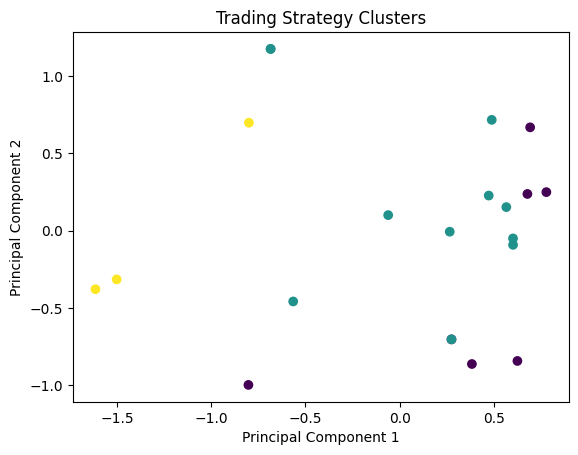

In [52]:


plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Trading Strategy Clusters")

plt.show()

In [53]:
df[
    [
        "strategy_type",
        "direction",
        "asset_type",
        "timeframe",
        "cluster"
    ]
].sort_values("cluster")

,strategy_type,direction,asset_type,timeframe,cluster
0,moving average crossover,NaN,NaN,NaN,0
7,mean reversion,Long/Short,NaN,NaN,0
5,breakout,Long/Short,NaN,any,0
4,continuation breakout strategy,NaN,NaN,NaN,0
13,mean reversion,Long,8854920,1-5 years,0
17,rsi trading strategy,Neutral,NaN,4-hour chart,0
19,momentum,NaN,NaN,NaN,0
1,breakout,NaN,NaN,daily,1
11,moving average crossover,NaN,stock,day,1
8,moving average crossover,NaN,NaN,4-12 months,1
